<a href="https://colab.research.google.com/github/nora-mohamed25/data-analysis-portfolio/blob/main/Project_13_Ai_Resume_Screening_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**`Ai Resume Screening`**
# 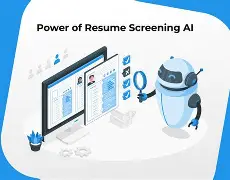


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('/content/ai_resume_screening.csv')
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  object 
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.6+ MB


In [ ]:
df.isnull().sum()

,0
years_experience,0
skills_match_score,0
education_level,0
project_count,0
resume_length,0
github_activity,0
shortlisted,0


In [ ]:
encoder = LabelEncoder()
df['education_level'] = encoder.fit_transform(df['education_level'])
df['shortlisted'] = encoder.fit_transform(df['shortlisted'])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  int64  
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  int64  
dtypes: float64(1), int64(6)
memory usage: 1.6 MB


In [ ]:
x = df.drop(['shortlisted'],axis=1)
y = df['shortlisted']

In [ ]:
x

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity
0,6,84.7,0,7,234,158
1,3,59.1,2,5,502,77
2,12,100.0,2,12,753,381
3,14,66.8,1,8,529,407
4,10,99.6,0,10,754,331
...,...,...,...,...,...,...
29995,9,77.4,0,13,691,434
29996,5,77.8,0,9,473,149
29997,1,64.6,0,7,247,82
29998,7,94.8,0,12,584,409


In [ ]:
y

,shortlisted
0,0
1,0
2,1
3,1
4,1
...,...
29995,1
29996,0
29997,0
29998,1


In [ ]:
# y_train_numeric = y_train.map({'Yes': 1, 'No': 0})
# y_test_numeric = y_test.map({'Yes': 1, 'No': 0})

In [ ]:
y.value_counts()

,count
shortlisted,
1,20966
0,9034


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split


In [ ]:
count_vectorizer = CountVectorizer()
count_vectorizer.fit_transform(x)
freq_term_matrix = count_vectorizer.transform(x)
tfidf = TfidfTransformer(norm="l2")
tfidf.fit(freq_term_matrix)
tf_idf_matrix = tfidf.fit_transform(freq_term_matrix)
print(tf_idf_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6 stored elements and shape (6, 6)>
  Coords	Values
  (0, 5)	1.0
  (1, 4)	1.0
  (2, 0)	1.0
  (3, 2)	1.0
  (4, 3)	1.0
  (5, 1)	1.0


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

In [ ]:
logreg = LogisticRegression()
logreg.fit(x_train, y_train)


LogisticRegression()

In [ ]:
y_pred = logreg.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print("Logreg Accuracy:", acc)

Logreg Accuracy: 0.9001666666666667


In [ ]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print("KNN Accuracy:", acc)

KNN Accuracy: 0.87


In [ ]:
svc = SVC()
svc.fit(x_train, y_train)

SVC()

In [ ]:
y_pred = svc.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print("SVC Accuracy:", acc)

SVC Accuracy: 0.8783333333333333


In [ ]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = dt.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", acc)

Decision Tree Accuracy: 0.8596666666666667


In [ ]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = rf.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", acc)

Random Forest Accuracy: 0.8973333333333333


In [ ]:
ensemble = VotingClassifier(estimators=[('logreg', logreg), ('knn', knn), ('svc', svc), ('dt', dt), ('rf', rf)], voting='hard')
ensemble.fit(x_train, y_train)

VotingClassifier(estimators=[('logreg', LogisticRegression()),
                             ('knn', KNeighborsClassifier()), ('svc', SVC()),
                             ('dt', DecisionTreeClassifier()),
                             ('rf', RandomForestClassifier())])

In [ ]:
y_pred = ensemble.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print("Ensemble Accuracy:", acc)

Ensemble Accuracy: 0.8923333333333333


In [ ]:
import numpy as np
new_data_point = np.array([[12,100.0,2,12,753,381]])
new_data_df = pd.DataFrame(new_data_point, columns=x_test.columns)
pred = ensemble.predict(new_data_df.values)
print(pred)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np
new_data_point = np.array([[6, 84.7, 2, 7, 234, 158]])
new_data_df = pd.DataFrame(new_data_point, columns=x_test.columns)
pred = ensemble.predict(new_data_df.values)
print(pred)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
